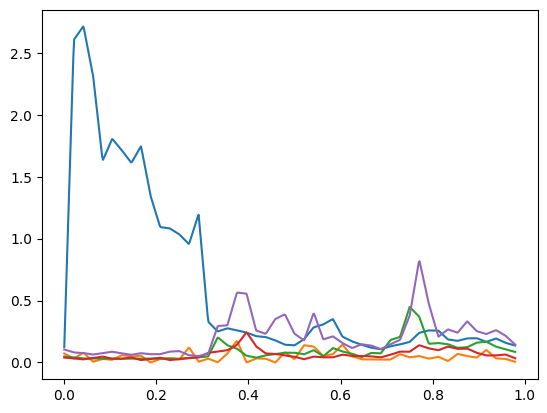

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfda 

from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.preprocessing.dim_reduction import FPCA
from sklearn.decomposition import PCA

from statsmodels.tsa.api import VAR


path = './dataset/2nd experiment/'

X_df = pd.read_csv(path + 'X.csv')
y_df = pd.read_csv(path + 'Y.csv')

y = y_df.to_numpy()

grid_points = np.arange(0, 1, 1/48)
data_matrix = X_df.to_numpy()

fd = skfda.FDataGrid(
    data_matrix=data_matrix,
    grid_points=grid_points,
)

split_idx = 1103

train_fd = fd[:-split_idx]
test_fd = fd[-split_idx:]

fd[:5].plot()
plt.show()

### Simulation (AdaFNN)

In [48]:
from pathlib import Path
from typing import Sequence, Tuple, List

import numpy as np
import pandas as pd

# ------------ helper functions (unchanged) ---------------- #
def random_grid(d: float = 0.02) -> List[float]:
    grid = [0.0]
    while 1.0 - grid[-1] > d:
        grid.append(grid[-1] + np.random.uniform(0, d))
    return grid + [1.0]

z1 = [20, 5, 5] + [1] * 47
z2 = [1] * 50
z2[0] = z2[2] = 5
z2[4] = z2[9] = 3
Z = [z1, z2, z2, [1] * 50]

def _phi(k):
    if k == 1:
        return lambda t: np.ones_like(t)
    return lambda t: np.sqrt(2.0) * np.cos((k - 1) * np.pi * t)

def _b1(t): return (4 - 16 * t) * ((0 <= t) & (t <= 0.25))
def _b2(t): return (4 - 16 * np.abs(0.5 - t)) * ((0.25 <= t) & (t <= 0.75))
# ---------------------------------------------------------- #


class DataGenerator:
    """
    Generate synthetic functional covariates X(t) and scalar responses Y
    following the simulation design in the paper.

    Parameters
    ----------
    grid : Sequence[float]
        Time points (must be sorted and lie in [0, 1]).
    case : int, default=1
        Which of the four simulation scenarios to use.
    me : float, default=1.0
        Variance of measurement error added to X.
    err : float, default=1.0
        Variance of noise added to Y.
    max_k : int, default=30
        Max. number of basis functions to use (≤ len(grid) for full rank).
    jitter : float, default=1e-6
        Tiny extra Gaussian noise always added to X (keeps Σ ≻ 0 even if me=0).
    """

    def __init__(
        self,
        grid: Sequence[float],
        case: int = 1,
        me: float = 1.0,
        err: float = 1.0,
        max_k: int = 30,
        jitter: float = 1e-6,
    ):
        self.t = np.asarray(grid, dtype=float)
        if (self.t[1:] < self.t[:-1]).any():
            raise ValueError("`grid` must be sorted ascending.")
        if me < 0 or err < 0 or jitter < 0:
            raise ValueError("Variances must be non-negative.")
        self.case = int(case)
        self.me = float(me)
        self.err = float(err)
        self.jitter = float(jitter)
        self.K = min(max_k, len(self.t))          # safe number of bases
        self.z = np.asarray(Z[self.case - 1])[: self.K]

    # ------------------------------------------------------------------ #
    def generate(self, n: int = 1000) -> None:
        if n <= self.K:
            raise ValueError("Need n > K to obtain full-rank covariance.")
        rng = np.random.default_rng()

        # coefficients c_{ik} = z_k r_{ik},  r_{ik} ~ U[-√3, √3]
        r = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(n, self.K))
        c = r * self.z            # (n, K)

        # basis matrix Φ_{kt}  (K × p)
        phi = np.vstack([_phi(k)(self.t) for k in range(1, self.K + 1)])

        # functional covariates X = C Φ   (n × p)
        X = c @ phi

        # scalar responses Y
        Y = np.zeros(n)
        if self.case == 1:
            Y = c[:, 2] ** 2                       # uses k=3 coefficient
        elif self.case == 4:
            beta1, beta2 = _b1(self.t), _b2(self.t)
            Y = np.trapz(beta2 * X, self.t, axis=1) + np.trapz(
                beta1 * X, self.t, axis=1
            ) ** 2
        else:  # cases 2 or 3
            Y = c[:, 4] ** 2                       # uses k=5 coefficient

        # add measurement & response noise
        X_noisy = X + rng.normal(0, np.sqrt(self.me), size=X.shape)
        if self.jitter > 0:
            X_noisy += rng.normal(0, self.jitter, size=X.shape)  # always keep Σ ≻ 0
        Y_noisy = Y[:, None] + rng.normal(0, np.sqrt(self.err), size=(n, 1))

        self.X, self.Y = X_noisy, Y_noisy
    # ------------------------------------------------------------------ #

    @staticmethod
    def _inner_product(f1: np.ndarray, f2: np.ndarray, t: np.ndarray) -> float:
        """Trapezoidal L² inner product between two discretised functions."""
        return np.trapz(f1 * f2, t)

    def save(self, folder: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Persist X, Y, t to CSV; return (X_df, Y_df, T_df)."""
        Path(folder).mkdir(parents=True, exist_ok=True)
        X_df = pd.DataFrame(self.X)
        Y_df = pd.DataFrame(self.Y)
        T_df = pd.DataFrame(self.t[None, :])
        X_df.to_csv(f"{folder}/X.csv", index=False, header=False)
        Y_df.to_csv(f"{folder}/Y.csv", index=False, header=False)
        T_df.to_csv(f"{folder}/T.csv", index=False, header=False)
        return X_df, Y_df, T_df


# ---------------- Example usage (unchanged) ---------------- #
d = 0.01
tp = random_grid(d)
DatGen = DataGenerator(tp, case=1, me=1.5, err=0.8)  # safe defaults
DatGen.generate(4000)
X_df, Y_df, T_df = DatGen.save("./dataset/2nd experiment/")


In [49]:
X_df.shape, T_df.shape

((4000, 212), (1, 212))

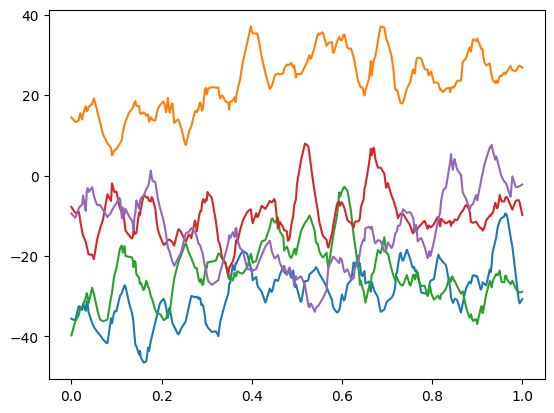

In [50]:
y = Y_df.to_numpy()

grid_points = T_df.to_numpy()
data_matrix = X_df.to_numpy()

fd = skfda.FDataGrid(
    data_matrix=data_matrix,
    grid_points=grid_points,
)

split_idx = 800

train_fd = fd[:-split_idx]
test_fd = fd[-split_idx:]

fd[:5].plot()
plt.show()

### PCA and FPCA compnents 

In [51]:
def fit_fpca(train_fd, n_components=5, n_basis=10, order=4):
    """Fits FPCA on functional data and returns the model and scores."""
    
    bspline_basis = BSplineBasis(n_basis=n_basis, order=order)
    fpca = FPCA(n_components=n_components, components_basis=bspline_basis)
    fpca.fit(train_fd)
    scores = fpca.transform(train_fd)
    
    return fpca, scores

def fit_pca(train_fd, n_components=5):
    """Fits classical PCA on discretized functional data and returns model and scores."""
    
    data = train_fd.data_matrix.squeeze()
    pca = PCA(n_components=n_components)
    pca.fit(data)
    scores = pca.transform(data)
    
    return pca, scores

def plot_components(fpca, pca):
    """Plots FPCA and PCA components side by side."""
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Left: FPCA components
    eval_points = fpca.components_[0].grid_points[0]
    for i in range(fpca.n_components):
        values = fpca.components_[i](eval_points)
        axs[0].plot(eval_points, values[0])
    axs[0].set_title("FPCA Components")
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Weight")
    axs[0].grid(True)


    # Right: Classical PCA components
    for i, component in enumerate(pca.components_):
        axs[1].plot(component)
    axs[1].set_title("PCA Components")
    axs[1].set_xlabel("Feature Index")
    axs[1].set_ylabel("Weight")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


# Example usage:
fpca_model, fpca_scores_df = fit_fpca(train_fd)
pca_model, pca_scores_df = fit_pca(train_fd)

print("Explained var FPCA:", fpca_model.explained_variance_ratio_.sum())
print("Explained var PCA:", pca_model.explained_variance_ratio_.sum())

plot_components(fpca_model, pca_model)


LinAlgError: Matrix is not positive definite